# Sentiment Analysis and Product Potential Evaluation on Amazon
### CS116 - Lập trình Python cho Máy học | Đề tài 4 - Nhóm 3

**Dataset:** Amazon Reviews 2018 - Electronics (Kaggle)  
**Models:** CNN, Bidirectional LSTM, BERT  
**Classification:** 3 classes - Negative (1-2 stars) / Neutral (3 stars) / Positive (4-5 stars)  
**Framework:** PyTorch (all models)  
**Sample size:** 100,000 reviews (balanced)

---

## 1. Setup and Data Loading

In [4]:
# ============================================================
# SETUP CHO GOOGLE COLAB - chạy cell này ĐẦU TIÊN
# ============================================================
# Colab đã có sẵn torch, transformers, sklearn, pandas...
# Chỉ cần cài thêm contractions và wordcloud:
!pip install -q contractions wordcloud

print("Đã cài xong thư viện bổ sung.")

Đã cài xong thư viện bổ sung.


In [5]:
# ============================================================
# TÌM FILE DATASET GỐC - Electronics.jsonl (Amazon Reviews 2023)
# ============================================================
# KHÁC bản cũ: đọc thẳng file review GỐC (cả ~44 triệu dòng) thay vì
# file electronics_100k_balanced.json đã trộn sẵn. Việc lấy mẫu 100k
# được làm ở cell sau bằng RESERVOIR SAMPLING (giữ đúng tỉ lệ sao gốc).
import os

FILE_NAME = "Electronics.jsonl"

# Các vị trí thường gặp (ưu tiên từ trên xuống). Thêm đường dẫn project của bạn.
candidate_paths = [
    f"/content/{FILE_NAME}",
    "/content/drive/Othercomputers/My Laptop/New project/data/raw/amazon_reviews_2023/reviews/Electronics.jsonl",
    f"/content/drive/MyDrive/{FILE_NAME}",
    f"/content/drive/MyDrive/datasets/{FILE_NAME}",
    f"/content/drive/MyDrive/reviews/{FILE_NAME}",
]

def _exists_any(p):
    return os.path.exists(p) or os.path.exists(p + ".gz")

file_path = None
for p in candidate_paths:
    if _exists_any(p):
        file_path = p if os.path.exists(p) else p + ".gz"
        break

# Nếu chưa thấy: mount Drive rồi dò toàn bộ
if file_path is None:
    try:
        from google.colab import drive
        if not os.path.exists("/content/drive"):
            print("Đang mount Google Drive...")
            drive.mount("/content/drive")
        for root, _, files in os.walk("/content/drive"):
            for fn in files:
                if fn in (FILE_NAME, FILE_NAME + ".gz"):
                    file_path = os.path.join(root, fn)
                    break
            if file_path:
                break
    except Exception as e:
        print("Không mount được Drive:", e)

if file_path is None:
    raise FileNotFoundError(
        f"Không tìm thấy {FILE_NAME}. Hãy đặt file vào /content/ hoặc trong "
        f"Google Drive (vd: .../data/raw/amazon_reviews_2023/reviews/) rồi chạy lại."
    )

print(f"Đã tìm thấy dataset gốc: {file_path}")

Đã tìm thấy dataset gốc: /content/drive/Othercomputers/My Laptop/New project/data/raw/amazon_reviews_2023/reviews/Electronics.jsonl


In [6]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("Libraries loaded successfully.")

PyTorch 2.10.0+cu128 | Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Libraries loaded successfully.


In [7]:
import json
# file_path đã được xác định ở cell SETUP phía trên.
# LẤY 100k review NGẪU NHIÊN trên toàn bộ dataset, GIỮ NGUYÊN tỉ lệ mất cân bằng
# gốc (KHÔNG cân bằng ở đây). Việc xử lý mất cân bằng làm sau bằng CLASS WEIGHTS
# ở khâu train, và CHỈ áp trên tập train (val/test giữ phân phối thật).
import random, gzip

SAMPLE_SIZE = 100_000
RANDOM_STATE = 42
MIN_WORDS = 5  # bỏ review quá ngắn (<5 từ)

def _open_maybe_gz(p):
    if str(p).endswith(".gz"):
        return gzip.open(p, "rt", encoding="utf-8")
    return open(p, "r", encoding="utf-8")

# --- Reservoir sampling: mẫu ngẫu nhiên thật trên TOÀN BỘ file, nhẹ RAM ---
print(f"Đang lấy mẫu ngẫu nhiên {SAMPLE_SIZE:,} review trên toàn bộ file (giữ tỉ lệ gốc)...")
rng = random.Random(RANDOM_STATE)
reservoir = []
n_seen = n_bad = n_short = 0

with _open_maybe_gz(file_path) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except Exception:
            n_bad += 1
            continue
        if len(str(rec.get('text', '') or '').split()) < MIN_WORDS:
            n_short += 1
            continue
        n_seen += 1
        if len(reservoir) < SAMPLE_SIZE:
            reservoir.append(rec)
        else:
            j = rng.randint(0, n_seen - 1)
            if j < SAMPLE_SIZE:
                reservoir[j] = rec
        if n_seen % 5_000_000 == 0:
            print(f"  ...đã quét {n_seen:,} review")

print(f"Quét xong: {n_seen:,} review hợp lệ"
      + (f", bỏ {n_short:,} review quá ngắn" if n_short else "")
      + (f", {n_bad:,} dòng lỗi" if n_bad else ""))

df_raw = pd.DataFrame(reservoir)

# --- Map schema Amazon 2023 (text/title/rating) -> tên cột notebook dùng ---
rename_map = {}
if 'text' in df_raw.columns:   rename_map['text'] = 'reviewText'
if 'title' in df_raw.columns:  rename_map['title'] = 'summary'
if 'rating' in df_raw.columns: rename_map['rating'] = 'overall'
df_raw = df_raw.rename(columns=rename_map)

df = df_raw[['reviewText', 'summary', 'overall']].dropna().copy()
df['overall'] = pd.to_numeric(df['overall'], errors='coerce')
df = df.dropna(subset=['overall'])

def assign_label(rating):
    if rating >= 4:
        return 2  # Positive
    elif rating == 3:
        return 1  # Neutral
    else:
        return 0  # Negative

df['label'] = df['overall'].apply(assign_label)

def build_text(row):
    s = str(row['summary'])
    r = str(row['reviewText'])
    if s.replace('.', '').isdigit():
        return r
    return s + " " + r

df['text'] = df.apply(build_text, axis=1)

timestamp_count = df['summary'].apply(lambda x: str(x).replace('.', '').isdigit()).sum()
print(f"Removed {timestamp_count:,} timestamp summaries ({timestamp_count/len(df)*100:.1f}% of data)")

df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"\nLabel distribution (GIỮ TỈ LỆ GỐC - mất cân bằng, sẽ xử lý bằng class weights):")
print(df['label'].value_counts().sort_index().rename({0: 'Negative', 1: 'Neutral', 2: 'Positive'}))
print(f"\nTỉ lệ %:")
print((df['label'].value_counts(normalize=True).sort_index()*100).round(2)
      .rename({0: 'Negative', 1: 'Neutral', 2: 'Positive'}))
df.head()


Đang lấy mẫu ngẫu nhiên 100,000 review trên toàn bộ file (giữ tỉ lệ gốc)...
  ...đã quét 5,000,000 review
  ...đã quét 10,000,000 review
  ...đã quét 15,000,000 review
  ...đã quét 20,000,000 review
  ...đã quét 25,000,000 review
  ...đã quét 30,000,000 review
  ...đã quét 35,000,000 review
Quét xong: 38,044,320 review hợp lệ, bỏ 5,842,624 review quá ngắn
Removed 3 timestamp summaries (0.0% of data)

Dataset shape: (100000, 5)

Label distribution (GIỮ TỈ LỆ GỐC - mất cân bằng, sẽ xử lý bằng class weights):
label
Negative    19075
Neutral      7174
Positive    73751
Name: count, dtype: int64

Tỉ lệ %:
label
Negative    19.08
Neutral      7.17
Positive    73.75
Name: proportion, dtype: float64


,reviewText,summary,overall,label,text
0,The Tozo A1 earbuds were pretty cost effective...,Great affordable earbuds,5.0,2,Great affordable earbuds The Tozo A1 earbuds w...
1,A really great product that's plug and Play. W...,Nice!!,5.0,2,Nice!! A really great product that's plug and ...
2,[[VIDEOID:b8f300b797dc7fc0f0c668479ea33dbe]] T...,BOSS MOVES✨...BUY ONE!!,5.0,2,BOSS MOVES✨...BUY ONE!! [[VIDEOID:b8f300b797dc...
3,Literally sets up in three minutes. Works per...,Highly Recommend.,5.0,2,Highly Recommend. Literally sets up in three m...
4,The Fire Stick was easy to set up and Alexa is...,Easy Access,5.0,2,Easy Access The Fire Stick was easy to set up ...


## 2. Exploratory Data Analysis (EDA)

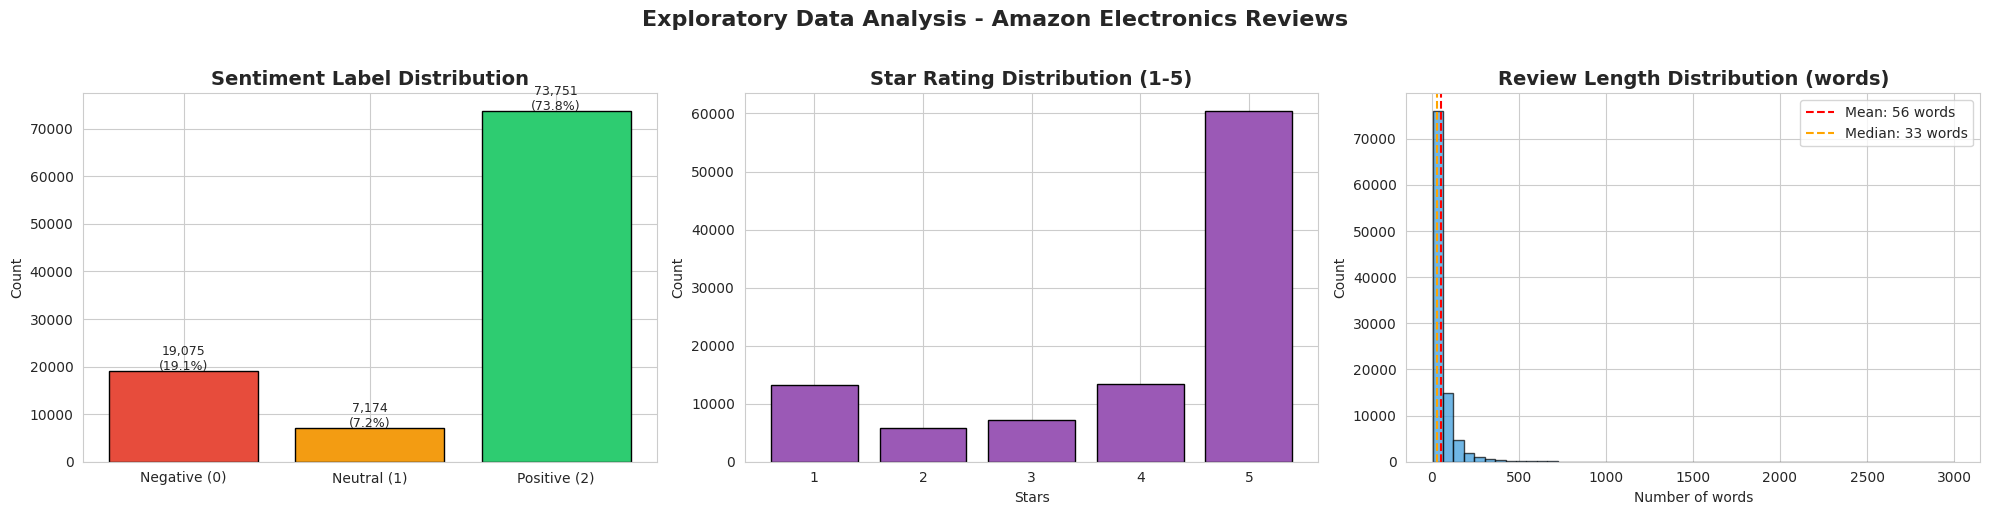

Total samples: 100,000
Average review length: 55.9 words
Median review length: 33.0 words

Class imbalance ratio (Positive / Negative): 3.9x


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Label distribution ---
label_counts = df['label'].value_counts().sort_index()
label_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
colors_label = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar(label_names, label_counts.values, color=colors_label, edgecolor='black')
axes[0].set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# --- Rating distribution ---
rating_counts = df['overall'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(int).astype(str), rating_counts.values,
            color='#9b59b6', edgecolor='black')
axes[1].set_title('Star Rating Distribution (1-5)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')

# --- Review length distribution ---
df['text_length'] = df['text'].str.split().str.len()
axes[2].hist(df['text_length'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[2].set_title('Review Length Distribution (words)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of words')
axes[2].set_ylabel('Count')
axes[2].axvline(df['text_length'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["text_length"].mean():.0f} words')
axes[2].axvline(df['text_length'].median(), color='orange', linestyle='--',
                label=f'Median: {df["text_length"].median():.0f} words')
axes[2].legend()

plt.suptitle('Exploratory Data Analysis - Amazon Electronics Reviews', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Total samples: {len(df):,}")
print(f"Average review length: {df['text_length'].mean():.1f} words")
print(f"Median review length: {df['text_length'].median():.1f} words")
print(f"\nClass imbalance ratio (Positive / Negative): {label_counts.get(2, 0) / max(label_counts.get(0, 1), 1):.1f}x")

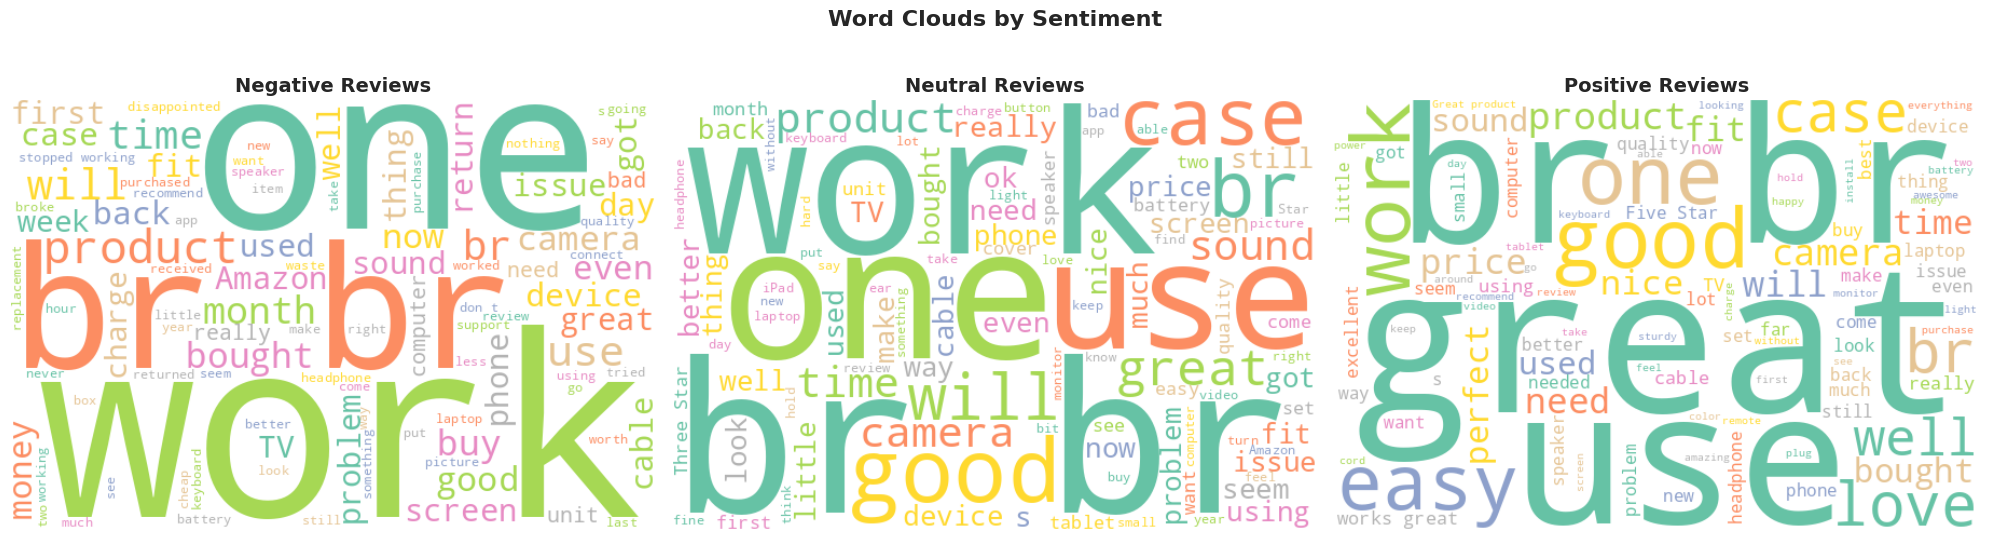

In [9]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sentiments = {0: ('Negative Reviews', '#e74c3c'),
              1: ('Neutral Reviews', '#f39c12'),
              2: ('Positive Reviews', '#2ecc71')}

for label_id, (title, color) in sentiments.items():
    text_data = ' '.join(df[df['label'] == label_id]['text'].values[:5000])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=100, colormap='Set2', random_state=42)
    wc.generate(text_data)
    axes[label_id].imshow(wc, interpolation='bilinear')
    axes[label_id].set_title(title, fontsize=14, fontweight='bold')
    axes[label_id].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

Two separate preprocessing pipelines:
- **Pipeline A (CNN/LSTM):** Lowercase, expand contractions, normalize slang, remove special chars.
- **Pipeline B (BERT):** Minimal (lowercase only) - BERT's WordPiece tokenizer handles the rest.

> Dữ liệu được chia **Train / Val / Test = 70 / 15 / 15** (stratified). Tập **Val** dùng để
> early stopping & chọn mô hình tốt nhất; tập **Test** chỉ dùng **một lần cuối** để báo cáo,
> đảm bảo đánh giá khách quan (không rò rỉ test set).

In [10]:
!pip install contractions -q
import contractions

# Chỉ giữ các từ lóng/viết tắt mà contractions.fix() KHÔNG xử lý
# (các dạng "dont/cant/isnt..." đã được contractions.fix() lo, nên bỏ để tránh trùng)
slang_dict = {
    "gr8": "great", "luv": "love", "idk": "i do not know",
    "imo": "in my opinion", "btw": "by the way", "u": "you",
    "ur": "your", "pls": "please", "thx": "thanks", "tbh": "to be honest",
}

def normalize_slang(text):
    words = text.split()
    return " ".join(slang_dict.get(w, w) for w in words)

def clean_for_dl(text):
    """Pipeline A: preprocessing for CNN/BiLSTM"""
    text = str(text).lower()
    text = contractions.fix(text)
    text = normalize_slang(text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_bert(text):
    """Pipeline B: minimal preprocessing for BERT"""
    return str(text).lower()

df['text_dl'] = df['text'].apply(clean_for_dl)
df['text_bert'] = df['text'].apply(clean_for_bert)

print("Preprocessing complete.")
print(f"\nExample (original):  {df['text'].iloc[0][:120]}...")
print(f"Example (DL clean):  {df['text_dl'].iloc[0][:120]}...")
print(f"Example (BERT clean): {df['text_bert'].iloc[0][:120]}...")

Preprocessing complete.

Example (original):  Great affordable earbuds The Tozo A1 earbuds were pretty cost effective compared to a lot of other products and still of...
Example (DL clean):  great affordable earbuds the tozo a1 earbuds were pretty cost effective compared to a lot of other products and still of...
Example (BERT clean): great affordable earbuds the tozo a1 earbuds were pretty cost effective compared to a lot of other products and still of...


## 3b. Xử lý mất cân bằng dữ liệu (Class Weights)


In [30]:
# ============================================================
# XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU - CLASS WEIGHTS
# ============================================================
# Dữ liệu giữ TỈ LỆ GỐC (mất cân bằng: ~76% Positive, ~7% Neutral). Thay vì sửa
# dữ liệu, ta điều chỉnh CÁCH MODEL HỌC: gán trọng số cao hơn cho lớp hiếm để
# model bị "phạt" nặng hơn khi đoán sai lớp đó -> không bị thiên về lớp đa số.
#
# - CHỈ tính trọng số từ tập TRAIN (không đụng val/test -> giữ phân phối thật).
# - 'balanced': weight_lop = n_samples / (n_classes * count_lop)
#   => lớp càng hiếm trọng số càng cao.
# - class_weights này được dùng lại cho cả CNN, BiLSTM (CrossEntropyLoss) và
#   BERT (WeightedTrainer) ở các cell phía dưới.
from sklearn.utils.class_weight import compute_class_weight

_classes = np.array([0, 1, 2])
_cw = compute_class_weight(class_weight='balanced', classes=_classes, y=y_train)
class_weights = torch.tensor(_cw, dtype=torch.float).to(device)

_names = ['Negative', 'Neutral', 'Positive']
print("CLASS WEIGHTS (tính từ tập train):")
for name, w, cnt in zip(_names, _cw, np.bincount(y_train, minlength=3)):
    print(f"  {name:9s}: weight = {w:5.3f}   (train count = {cnt:,})")
print("\n=> Lớp hiếm nhất có trọng số cao nhất, lớp đa số thấp nhất.")
print("=> Dữ liệu KHÔNG đổi (vẫn mất cân bằng); chỉ model học có trọng số.")


CLASS WEIGHTS (tính từ tập train):
  Negative : weight = 1.748   (train count = 13,352)
  Neutral  : weight = 4.646   (train count = 5,022)
  Positive : weight = 0.452   (train count = 51,626)

=> Lớp hiếm nhất có trọng số cao nhất, lớp đa số thấp nhất.
=> Dữ liệu KHÔNG đổi (vẫn mất cân bằng); chỉ model học có trọng số.


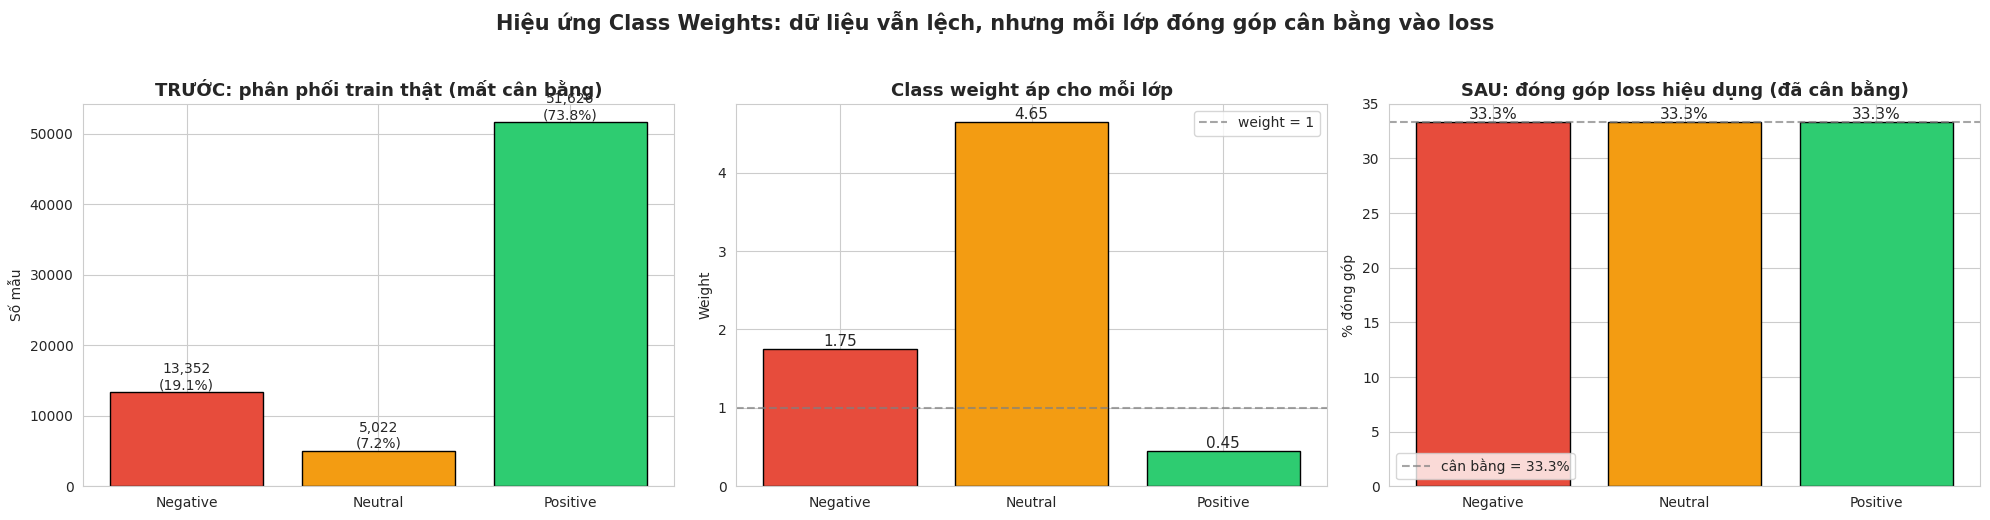

Bảng tóm tắt:
Lớp           Count   % thật   Weight  % hiệu dụng
Negative     13,352    19.1%     1.75        33.3%
Neutral       5,022     7.2%     4.65        33.3%
Positive     51,626    73.8%     0.45        33.3%

=> Cột '% hiệu dụng' xấp xỉ 33.3% mỗi lớp = class weights đã cân bằng đóng góp của 3 lớp.


In [31]:
# ============================================================
# EDA SAU KHI XỬ LÝ MẤT CÂN BẰNG (hiệu ứng của Class Weights)
# ============================================================
# Lưu ý: class weights KHÔNG đổi dữ liệu (vẫn lệch 17/7/76). Nó đổi "sức nặng"
# mỗi lớp khi model học. Biểu đồ dưới so sánh: (a) phân phối THẬT của tập train,
# và (b) "đóng góp trọng số hiệu dụng" của mỗi lớp = count * weight -> cân bằng.
import numpy as np
import matplotlib.pyplot as plt

_names = ['Negative', 'Neutral', 'Positive']
_colors = ['#e74c3c', '#f39c12', '#2ecc71']

counts = np.bincount(y_train, minlength=3)
cw_np = class_weights.detach().cpu().numpy()
effective = counts * cw_np                      # đóng góp loss hiệu dụng mỗi lớp
eff_pct = effective / effective.sum() * 100
raw_pct = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (1) Phân phối THẬT - trước xử lý
b1 = axes[0].bar(_names, counts, color=_colors, edgecolor='black')
axes[0].set_title('TRƯỚC: phân phối train thật (mất cân bằng)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số mẫu')
for bar, c, p in zip(b1, counts, raw_pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{c:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)

# (2) Trọng số mỗi lớp
b2 = axes[1].bar(_names, cw_np, color=_colors, edgecolor='black')
axes[1].set_title('Class weight áp cho mỗi lớp', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='weight = 1')
axes[1].legend()
for bar, w in zip(b2, cw_np):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{w:.2f}', ha='center', va='bottom', fontsize=11)

# (3) Đóng góp hiệu dụng SAU khi nhân weight -> cân bằng
b3 = axes[2].bar(_names, eff_pct, color=_colors, edgecolor='black')
axes[2].set_title('SAU: đóng góp loss hiệu dụng (đã cân bằng)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('% đóng góp')
axes[2].axhline(100/3, color='gray', linestyle='--', alpha=0.7, label='cân bằng = 33.3%')
axes[2].legend()
for bar, p in zip(b3, eff_pct):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('Hiệu ứng Class Weights: dữ liệu vẫn lệch, nhưng mỗi lớp đóng góp cân bằng vào loss',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Bảng tóm tắt:")
print(f"{'Lớp':10s} {'Count':>8s} {'% thật':>8s} {'Weight':>8s} {'% hiệu dụng':>12s}")
for n, c, rp, w, ep in zip(_names, counts, raw_pct, cw_np, eff_pct):
    print(f"{n:10s} {c:>8,} {rp:>7.1f}% {w:>8.2f} {ep:>11.1f}%")
print("\n=> Cột '% hiệu dụng' xấp xỉ 33.3% mỗi lớp = class weights đã cân bằng đóng góp của 3 lớp.")

## 4. CNN Model (Convolutional Neural Network)

CNN uses 1D convolutional filters that slide across word sequences to detect local patterns (n-grams) like "not good", "very bad", etc. Good at capturing short phrase-level features.

In [11]:
MAX_WORDS = 20000
MAX_LEN = 150
BATCH_SIZE = 128

X_dl = df['text_dl'].values
y_dl = df['label'].values

# === Chia TRAIN / VAL / TEST = 70 / 15 / 15 (stratified) ===
# Bước 1: tách 30% ra làm (val + test)
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_dl, y_dl, test_size=0.30, random_state=42, stratify=y_dl
)
# Bước 2: chia đôi phần 30% -> 15% val, 15% test
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Vocabulary CHỈ xây từ tập train (tránh rò rỉ thông tin từ val/test)
word_counts = Counter()
for text in X_train_text:
    word_counts.update(text.split())

vocab = {'<PAD>': 0, '<OOV>': 1}
for word, _ in word_counts.most_common(MAX_WORDS - 2):
    vocab[word] = len(vocab)

def texts_to_sequences(texts, vocab, max_len):
    sequences = []
    for text in texts:
        seq = [vocab.get(w, 1) for w in text.split()][:max_len]
        seq = seq + [0] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

X_train_seq = texts_to_sequences(X_train_text, vocab, MAX_LEN)
X_val_seq   = texts_to_sequences(X_val_text,   vocab, MAX_LEN)
X_test_seq  = texts_to_sequences(X_test_text,  vocab, MAX_LEN)

train_ds = TensorDataset(torch.tensor(X_train_seq, dtype=torch.long),
                         torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val_seq, dtype=torch.long),
                         torch.tensor(y_val, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test_seq, dtype=torch.long),
                         torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)   # dùng để early stopping
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)   # CHỈ dùng 1 lần cuối để báo cáo

print(f"Vocabulary size: {len(vocab)}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Val labels:   {np.bincount(y_val)}")
print(f"Test labels:  {np.bincount(y_test)}")
# === CLASS WEIGHTS xử lý mất cân bằng - CHỈ tính từ tập TRAIN ===
# Lớp hiếm (Neutral) được trọng số cao hơn -> model bị "phạt" nặng hơn khi đoán
# sai lớp đó, buộc chú ý tới lớp thiểu số. KHÔNG đụng tới val/test (giữ phân phối thật).
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1, 2])
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = torch.tensor(cw, dtype=torch.float).to(device)
print(f"\nClass weights (Neg/Neu/Pos): {cw.round(3)}")
print("(lớp càng hiếm trọng số càng cao)")


Vocabulary size: 20000
Train: 70000 | Val: 15000 | Test: 15000
Train labels: [13352  5022 51626]
Val labels:   [ 2861  1076 11063]
Test labels:  [ 2862  1076 11062]

Class weights (Neg/Neu/Pos): [1.748 4.646 0.452]
(lớp càng hiếm trọng số càng cao)


In [12]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=5)
        self.conv2 = nn.Conv1d(128, 64, kernel_size=5)
        self.fc1 = nn.Linear(64, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.max(dim=2).values
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

cnn_model = CNNModel(len(vocab), 128, 3).to(device)
print(f"CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(cnn_model)

CNN parameters: 2,687,427
CNNModel(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (conv1): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  (conv2): Conv1d(128, 64, kernel_size=(5,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


In [13]:
import copy

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3, patience=2, class_weights=None):
    """Train với early stopping dựa trên VALIDATION loss (không dùng test set)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=1, factor=0.5
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)  # áp class weights chống mất cân bằng
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [], 'lr': []}

    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += len(y_batch)

        # Đánh giá trên tập VALIDATION (không phải test)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item() * len(y_batch)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += len(y_batch)

        epoch_val_loss = val_loss / val_total
        current_lr = optimizer.param_groups[0]['lr']

        history['loss'].append(total_loss / total)
        history['accuracy'].append(correct / total)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(val_correct / val_total)
        history['lr'].append(current_lr)

        print(f"Epoch {epoch+1}/{epochs} - "
              f"loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f} - "
              f"val_loss: {epoch_val_loss:.4f} - val_acc: {history['val_accuracy'][-1]:.4f} - "
              f"lr: {current_lr:.1e}")

        scheduler.step(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best weights (val_loss: {best_val_loss:.4f})")

    return history

# Train CNN: early stopping theo val_loader, đánh giá cuối trên test_loader
history_cnn = train_model(cnn_model, train_loader, val_loader, epochs=10, patience=2, class_weights=class_weights)

# Accuracy/Loss BÁO CÁO lấy từ tập TEST (đánh giá độc lập, đúng 1 lần)
cnn_model.eval()
_crit = nn.CrossEntropyLoss(weight=class_weights)
_tl, _tc, _tn = 0, 0, 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = cnn_model(Xb)
        _tl += _crit(out, yb).item() * len(yb)
        _tc += (out.argmax(1) == yb).sum().item(); _tn += len(yb)
cnn_acc = _tc / _tn
cnn_loss = _tl / _tn
print(f"\nCNN TEST Accuracy: {cnn_acc:.4f} | TEST Loss: {cnn_loss:.4f}")

Epoch 1/10 - loss: 0.7985 - acc: 0.6959 - val_loss: 0.6654 - val_acc: 0.7700 - lr: 1.0e-03
Epoch 2/10 - loss: 0.6056 - acc: 0.7896 - val_loss: 0.6235 - val_acc: 0.7820 - lr: 1.0e-03
Epoch 3/10 - loss: 0.5048 - acc: 0.8293 - val_loss: 0.6336 - val_acc: 0.7900 - lr: 1.0e-03
Epoch 4/10 - loss: 0.4066 - acc: 0.8604 - val_loss: 0.7517 - val_acc: 0.8451 - lr: 1.0e-03
Early stopping at epoch 4 (no improvement for 2 epochs)
Restored best weights (val_loss: 0.6235)

CNN TEST Accuracy: 0.7815 | TEST Loss: 0.6201


=== CNN Classification Report ===
              precision    recall  f1-score   support

    Negative       0.84      0.62      0.72      2862
     Neutral       0.22      0.71      0.34      1076
    Positive       0.97      0.83      0.89     11062

    accuracy                           0.78     15000
   macro avg       0.68      0.72      0.65     15000
weighted avg       0.89      0.78      0.82     15000



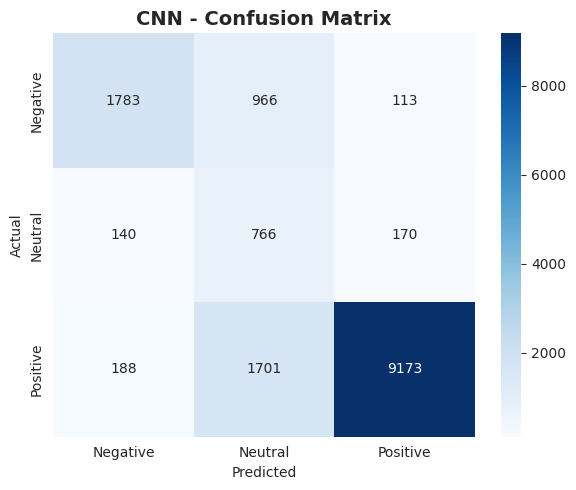

In [14]:
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']

def predict_all(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            outputs = model(X_batch.to(device))
            all_preds.append(outputs.argmax(1).cpu().numpy())
    return np.concatenate(all_preds)

y_pred_cnn = predict_all(cnn_model, test_loader)

print("=== CNN Classification Report ===")
print(classification_report(y_test, y_pred_cnn, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 5. Bidirectional LSTM Model (Long Short-Term Memory)

LSTM reads text sequentially and maintains a memory state, capturing long-range dependencies between words. Bidirectional LSTM reads both left-to-right and right-to-left for richer context understanding.

In [15]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, dropout=0.2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        x = torch.cat((hidden[-2], hidden[-1]), dim=1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

lstm_model = LSTMModel(len(vocab), 128, 64, 3).to(device)
print(f"BiLSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(lstm_model)

BiLSTM parameters: 2,667,779
LSTMModel(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True, dropout=0.2, bidirectional=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


In [16]:
history_lstm = train_model(lstm_model, train_loader, val_loader, epochs=10, patience=2, class_weights=class_weights)

# Accuracy/Loss BÁO CÁO lấy từ tập TEST (độc lập)
lstm_model.eval()
_crit = nn.CrossEntropyLoss(weight=class_weights)
_tl, _tc, _tn = 0, 0, 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = lstm_model(Xb)
        _tl += _crit(out, yb).item() * len(yb)
        _tc += (out.argmax(1) == yb).sum().item(); _tn += len(yb)
lstm_acc = _tc / _tn
lstm_loss = _tl / _tn
print(f"\nBiLSTM TEST Accuracy: {lstm_acc:.4f} | TEST Loss: {lstm_loss:.4f}")

Epoch 1/10 - loss: 0.7309 - acc: 0.7458 - val_loss: 0.6148 - val_acc: 0.7776 - lr: 1.0e-03
Epoch 2/10 - loss: 0.5802 - acc: 0.8084 - val_loss: 0.5900 - val_acc: 0.8138 - lr: 1.0e-03
Epoch 3/10 - loss: 0.4918 - acc: 0.8399 - val_loss: 0.5980 - val_acc: 0.8267 - lr: 1.0e-03
Epoch 4/10 - loss: 0.4126 - acc: 0.8661 - val_loss: 0.6562 - val_acc: 0.8241 - lr: 1.0e-03
Early stopping at epoch 4 (no improvement for 2 epochs)
Restored best weights (val_loss: 0.5900)

BiLSTM TEST Accuracy: 0.8177 | TEST Loss: 0.6009


=== BiLSTM Classification Report ===
              precision    recall  f1-score   support

    Negative       0.79      0.75      0.77      2862
     Neutral       0.26      0.64      0.37      1076
    Positive       0.97      0.85      0.91     11062

    accuracy                           0.82     15000
   macro avg       0.68      0.75      0.68     15000
weighted avg       0.89      0.82      0.84     15000



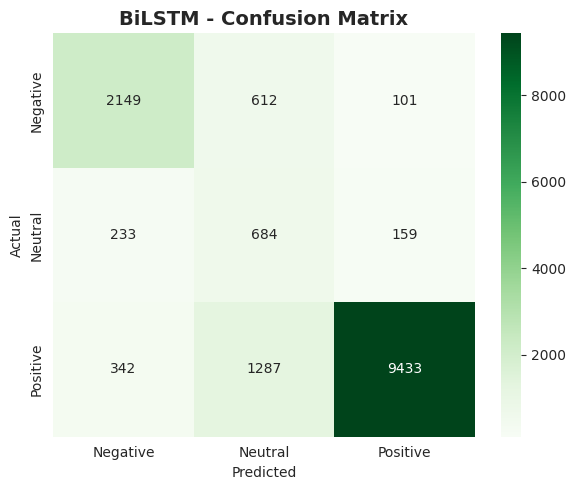

In [17]:
y_pred_lstm = predict_all(lstm_model, test_loader)

print("=== BiLSTM Classification Report ===")
print(classification_report(y_test, y_pred_lstm, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('BiLSTM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6. BERT Model (Bidirectional Encoder Representations from Transformers)

BERT is a pre-trained transformer model by Google that understands bidirectional context. Fine-tuning BERT on our dataset leverages knowledge from massive text corpora, achieving state-of-the-art performance on sentiment classification.

**Note:** This section requires GPU. On Kaggle, go to Settings -> Accelerator -> GPU T4 x2.

In [18]:
import gc

cnn_model.cpu()
lstm_model.cpu()
torch.cuda.empty_cache()
gc.collect()

if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    used = torch.cuda.memory_allocated(0) / 1e9
    print(f"GPU memory freed. VRAM: {total:.1f} GB total, ~{total - used:.1f} GB free")

from transformers import BertTokenizer

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 128 token: bao phủ phần lớn review (TB ~85 từ), cân bằng độ chính xác và chi phí GPU
BERT_MAX_LEN = 128

print(f"\nBERT using same dataset as CNN/BiLSTM: {len(df)} samples")
print(f"Max token length: {BERT_MAX_LEN}")

X_bert = df['text_bert'].values
y_bert = df['label'].values

# Chia TRAIN / VAL / TEST = 70 / 15 / 15 (cùng random_state -> cùng cách chia với CNN/LSTM)
X_train_bert, X_temp_bert, y_train_bert, y_temp_bert = train_test_split(
    X_bert, y_bert, test_size=0.30, random_state=42, stratify=y_bert
)
X_val_bert, X_test_bert, y_val_bert, y_test_bert = train_test_split(
    X_temp_bert, y_temp_bert, test_size=0.50, random_state=42, stratify=y_temp_bert
)

print(f"\nEncoding {len(X_train_bert)} train + {len(X_val_bert)} val + {len(X_test_bert)} test...")
train_encodings = bert_tokenizer(
    X_train_bert.tolist(), padding='max_length', truncation=True,
    max_length=BERT_MAX_LEN, return_tensors='pt'
)
val_encodings = bert_tokenizer(
    X_val_bert.tolist(), padding='max_length', truncation=True,
    max_length=BERT_MAX_LEN, return_tensors='pt'
)
test_encodings = bert_tokenizer(
    X_test_bert.tolist(), padding='max_length', truncation=True,
    max_length=BERT_MAX_LEN, return_tensors='pt'
)
print("Tokenization complete.")

GPU memory freed. VRAM: 42.4 GB total, ~42.4 GB free


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


BERT using same dataset as CNN/BiLSTM: 100000 samples
Max token length: 128

Encoding 70000 train + 15000 val + 15000 test...
Tokenization complete.


In [19]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train_bert)
val_dataset   = SentimentDataset(val_encodings,   y_val_bert)
test_dataset  = SentimentDataset(test_encodings,  y_test_bert)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")

Train dataset: 70000 samples
Val dataset:   15000 samples
Test dataset:  15000 samples


In [20]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=3
)
bert_model.to(device)

print(f"Model parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    # macro: trung bình đều giữa 3 lớp, không thiên về lớp đa số
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'macro_f1': f1, 'precision': precision, 'recall': recall}

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',   # chọn best theo macro F1
    warmup_steps=200,
    weight_decay=0.01,
    fp16=True,
    gradient_checkpointing=True,         # bật 1 lần ở đây là đủ
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataloader_num_workers=0,
    report_to='none',
)


# === Trainer có CLASS WEIGHTS cho BERT (xử lý mất cân bằng) ===
# Trainer mặc định không dùng class weights. Ta override compute_loss để đưa
# trọng số lớp vào CrossEntropyLoss (dùng cùng class_weights đã tính từ TRAIN).
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self._class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,            # chọn best model trên VAL, không phải test
    compute_metrics=compute_metrics,
    class_weights=class_weights,   # áp class weights chống mất cân bằng
)

print("\nStarting BERT training...")
trainer.train()
val_results = trainer.evaluate(val_dataset)
print(f"\nBERT VALIDATION results: {val_results}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 109,484,547

Starting BERT training...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BERT VALIDATION results: {'eval_loss': 0.6888915300369263, 'eval_accuracy': 0.9014, 'eval_macro_f1': 0.7607200756049862, 'eval_precision': 0.749800714788544, 'eval_recall': 0.7739328520756238, 'eval_runtime': 26.4123, 'eval_samples_per_second': 567.916, 'eval_steps_per_second': 70.99, 'epoch': 3.0}


=== BERT Classification Report ===
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      2862
     Neutral       0.42      0.52      0.47      1076
    Positive       0.97      0.95      0.96     11062

    accuracy                           0.90     15000
   macro avg       0.75      0.77      0.76     15000
weighted avg       0.91      0.90      0.90     15000



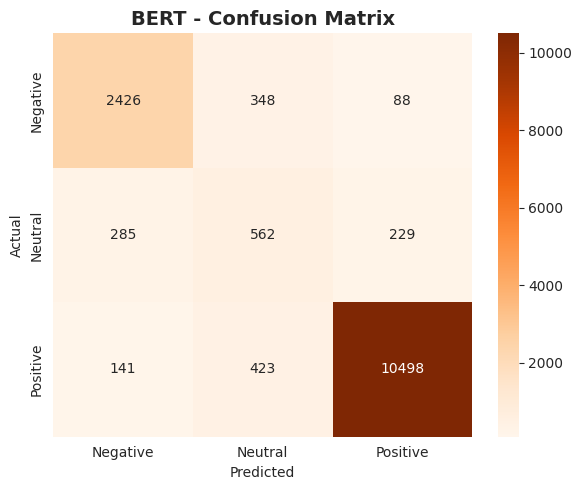

In [21]:
bert_preds = trainer.predict(test_dataset)
y_pred_bert = bert_preds.predictions.argmax(-1)

print("=== BERT Classification Report ===")
print(classification_report(y_test_bert, y_pred_bert, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('BERT - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Model Comparison

In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score

def metric_row(y_true, y_pred, acc):
    return {
        'Accuracy': acc,
        'Macro_F1': f1_score(y_true, y_pred, average='macro'),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro'),
    }

comparison = {
    'CNN':  metric_row(y_test, y_pred_cnn, cnn_acc),
    'BiLSTM': metric_row(y_test, y_pred_lstm, lstm_acc),
    'BERT': metric_row(y_test_bert, y_pred_bert, accuracy_score(y_test_bert, y_pred_bert)),
}

results_df = pd.DataFrame(comparison).T.round(4)
results_df = results_df.sort_values('Macro_F1', ascending=False)
print("=" * 60)
print("MODEL COMPARISON - Sentiment Analysis (3-class, macro avg)")
print("=" * 60)
print(results_df.to_string())
print("=" * 60)
print(f"\nBest model by Macro F1: {results_df.index[0]} "
      f"({results_df.iloc[0]['Macro_F1']:.4f})")

MODEL COMPARISON - Sentiment Analysis (3-class, macro avg)
        Accuracy  Macro_F1  Precision  Recall
BERT      0.8991    0.7585     0.7476  0.7730
BiLSTM    0.8177    0.6841     0.6756  0.7464
CNN       0.7815    0.6503     0.6793  0.7214

Best model by Macro F1: BERT (0.7585)


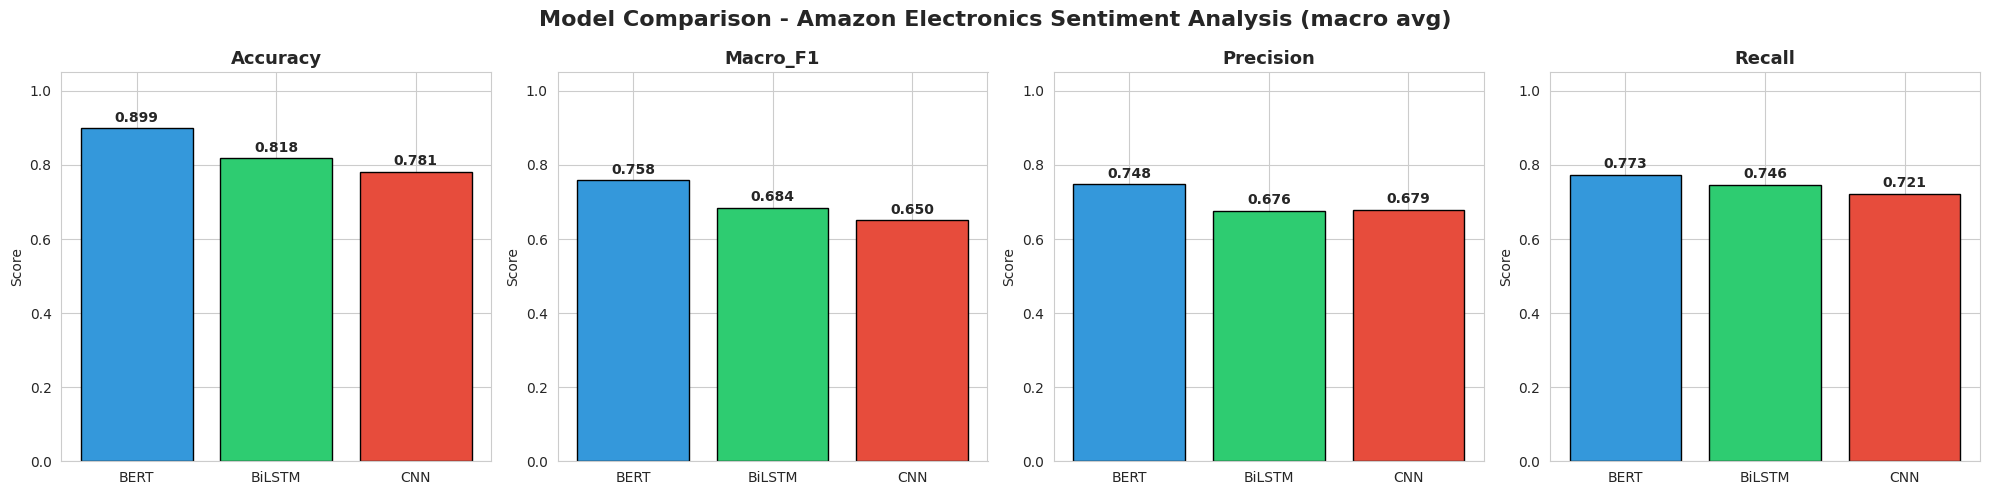

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['Accuracy', 'Macro_F1', 'Precision', 'Recall']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors, edgecolor='black')
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Comparison - Amazon Electronics Sentiment Analysis (macro avg)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

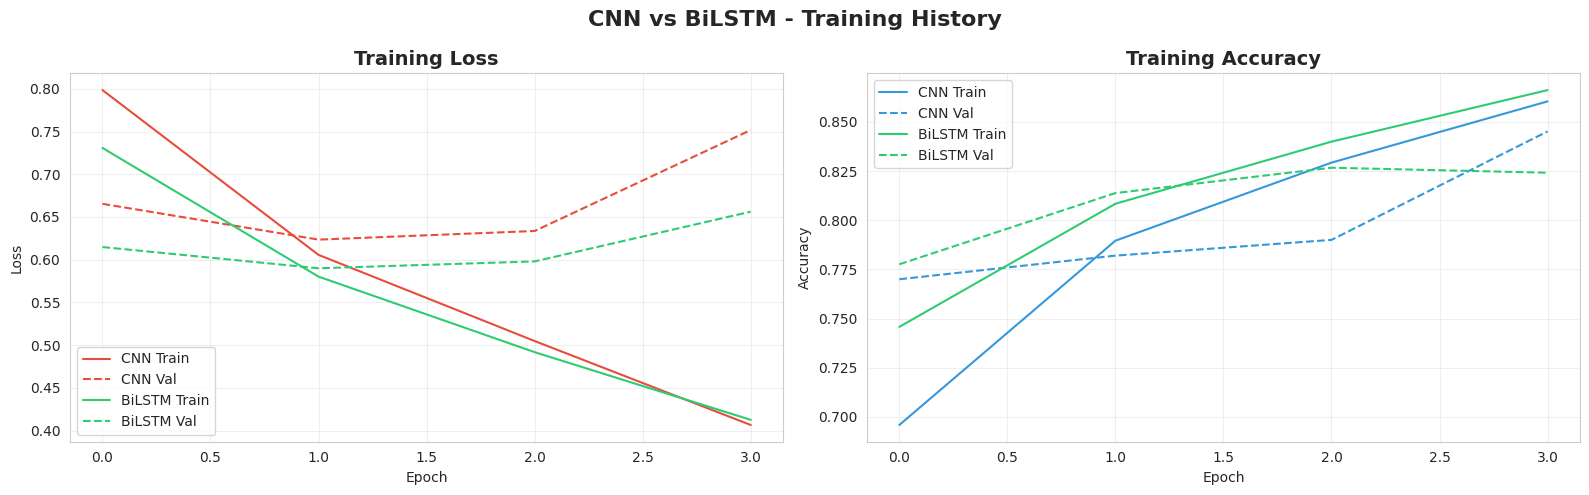

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for key, label, color in [('loss', 'Loss', '#e74c3c'), ('accuracy', 'Accuracy', '#3498db')]:
    ax = axes[0] if key == 'loss' else axes[1]
    ax.plot(history_cnn[key], label='CNN Train', linestyle='-', color=color)
    ax.plot(history_cnn[f'val_{key}'], label='CNN Val', linestyle='--', color=color)
    ax.plot(history_lstm[key], label='BiLSTM Train', linestyle='-', color='#2ecc71')
    ax.plot(history_lstm[f'val_{key}'], label='BiLSTM Val', linestyle='--', color='#2ecc71')
    ax.set_title(f'Training {label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('CNN vs BiLSTM - Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Prediction Pipeline (Demo)

Demonstrate sentiment prediction on new unseen text using all three trained models.

In [25]:
LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

def predict_dl(text, model, word_vocab, max_len=MAX_LEN):
    """Predict sentiment using CNN or BiLSTM model."""
    cleaned = clean_for_dl(text)
    seq = [word_vocab.get(w, 1) for w in cleaned.split()][:max_len]
    seq = seq + [0] * (max_len - len(seq))
    tensor = torch.tensor([seq], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        output = model(tensor)
    probs = torch.softmax(output, dim=1).cpu().numpy()[0]
    label_idx = probs.argmax()
    return LABEL_MAP[label_idx], probs[label_idx], probs

def predict_bert_text(text, model, tokenizer, max_len=BERT_MAX_LEN):
    """Predict sentiment using BERT model."""
    inputs = tokenizer(
        text.lower(), return_tensors='pt', truncation=True,
        padding=True, max_length=max_len
    )
    dev = next(model.parameters()).device
    inputs = {k: v.to(dev) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    label_idx = probs.argmax()
    return LABEL_MAP[label_idx], probs[label_idx], probs

In [38]:
cnn_model.to(device)
lstm_model.to(device)

demo_reviews = [
    # === SARCASM / MỈA MAI (Rating 1-2★ nhưng chứa từ positive) ===
    # [1] Rating: 1★ - "perfect condition" nhưng sản phẩm tệ, kết luận "piece of crap"
    "Piece of Crap The cable looked like it was in perfect condition so when I plugged it into my T.V. it was frizzy. I gave the card to my little brothers to see if it worked on their PS3 they plugged it in and snowflakes was fallin from the T.V. screen.I will never ever ever ever buy another HDMI card from this seller it SUCKS!!!!Do not ever buy this Junk, this is a true meaning of a piece of crap.",
    # [2] Rating: 2★ - "Good protection, easy to install, nice looking, durable" nhưng rating 2
    "Didn't work well with my screen protector Good protection, easy to install, nice looking, durable.But when I put it in my pocket the wrap around lip apparently peels off a bit, gets under my screen protector, and lifts it up which allows lint to get under the screen protector.I switched to a softer Amazon basics silicone case and I no longer have the problem.",
    # [3] Rating: 2★ - So sánh "touchpad is faster by a mile", "might be good for business"
    "slow and confusing I bought this to replace my HP touchpad, there was no comparison. The touchpad, is faster by a mile and starts up in seconds. I have since bought another touchpad. I think the slate might be good for business, but not for web brousing",
    # [4] Rating: 1★ - "used to be good", "had good results" nhưng sản phẩm mới tệ
    "Memorex DVD+RW disks used to be good I have been using Memorex DVD+RW disks for a few years. Up until this particular version with the little stars on the disks I had good results.These more recent disks might burn once or twice. After that, forget it!! Burn failures galore.Use another brand.",

    # === MIXED SENTIMENT (Rating 3★ - vừa khen vừa chê) ===
    # [5] Rating: 3★ - Tự tính: audio 5★ + FM 1★ = 3★
    "FM is terrible I give this product 3 stars using the following math.As an player for audio files - 5 stars.As an FM receiver - 1 star. Reception is horrid. Of the channels that do come in, most are grainy with noise. Of the one clear station I could get, it sounded hollow, distant, and was very mono sounding in stereo mode. FM reception is very important to me so I returned this product.",
    # [6] Rating: 3★ - "best GPS" NHƯNG "battery is worthless"
    "great unit terrible battery! This is probably the best GPS I have owned yet but the battery is worthless",
    # [7] Rating: 3★ - Khen tablet nhưng chê Windows RT, đã trả lại
    "Nicely executed but where does it fit in? This is a very nice tablet, for media consumption and email it's great. The 16 hour battery life with the keyboard attached make this the perfect companion for long flight. It's light, thin and well made.The problem is adding RT to the end of Windows eliminates all the benefits of the Windows platform, ie application compatibility. I returned it for a ThinkPad Tablet 2.",
    # [8] Rating: 3★ - "optically amazing" NHƯNG "construction problems", đã trả lại
    "Fairy Dust I would buy this lens again in a heartbeat. As soon as Nikon fixes the construction problems. The thread/baffle imperfections do not bother me, but every copy I have seen has the very shiny particles clinging to the inside of the barrel near the 2nd element. I returned mine and will get another sometime in the future. The lens is optically amazing and the imperfections apparently are not affecting image quality, at least not now!",

    # === IMPLICIT NEGATIVE (Rating 1-2★, không dùng từ negative rõ ràng) ===
    # [9] Rating: 1★ - "paying more than 100% extra just for the name tag"
    "Way over priced Compare the specs to other laptops that is not devoted to Steve and you will find that you are paying more than %100 extra just for the name tag!",
    # [10] Rating: 1★ - Factual complaint, "too big", "cannot be adjusted"
    "This Strap is TOO Big and can easily slip off of your rist!! The feedback you left about this order was removed.Don't know why my comments were removed so I re-entered them, the wrist strap is too big and cannot be adjusted to a tight fit.",
    # [11] Rating: 2★ - "lasted three years" có vẻ neutral, "switches are USELESS"
    "Headphone lasted three years Three years later, it died. For the price, I guess it did its job.The switches on the headphone are completely USELESS. There is no sound difference! It is a lie.",
    # [12] Rating: 2★ - Khen "Well built, quality made" nhưng khuyên mua loại khác
    "Well built, quality made filter, but It needs a coated lens. This filter causes flare distortion because it has a highly reflective surface. Spend more and buy the coated version.",

    # === IMPLICIT POSITIVE (Rating 5★, không dùng từ positive rõ ràng) ===
    # [13] Rating: 5★ - "Lots of handle turning though" nghe hơi tiêu cực
    "This works! Lots of handle turning though This mechanism cleans CD's and DVD's very well to stop them from skipping or jumping. You can sit and spin the handle while watching TV.",
    # [14] Rating: 5★ - Technical, factual, "cost effective", "recommended"
    "Works as advertised I purchased this for my Synology NAS. This was a very cost effective solution for adding an additional 2 Gb of RAM to the NAS. Installation was a breeze and the RAM was recognized by the system immediately. Recommended",
    # [15] Rating: 5★ - Rất ngắn, factual
    "Basic and powerful Use it to connect my laptop to a monitor and it works as it should. I recommend and would buy again.",
    # [16] Rating: 5★ - "What you expect from Apple" - có thể hiểu 2 nghĩa
    "What you expect from Apple Bought this for my son as a birthday present. Just like every other Apple product I have owned, it works flawlessly. Easy setup, easy to sync from his old broken iPod. He loves this and takes it EVERYWHERE we go.",

    # === COMPLEX NEGATIVE (Rating 1-2★, dài, có tín hiệu cả 2 chiều) ===
    # [17] Rating: 1★ - Khen nhẹ "hate giving bad reviews", "give them a second chance"
    "Broke... I ordered this with a new hard drive. Installed them in my old case and never touched them again till. Recently I decided to order a new case and move everything over. During the swap out I pulled this out of the hard drive and the clip on the end that holds the cable in broke. The cable was literally touched twice... Maybe I just got that one faulty one... Going to order another one and give them a second chance. Would really love to change this to a higher rating I hate giving bad reviews.",
    # [18] Rating: 1★ - "a lot of great reviews" nhưng card failed ở China
    "SD card failed while taking pictures in China The bad news is that my 64gb SCT SD card failed while I was traveling through China. Fortunately for me I also had a back up SD card. The worse news is that I could not recover any of the lost pictures. When I returned home I tried using recovery software I found free on the internet. None of it worked.",
    # [19] Rating: 1★ - "I don't know what went wrong" - mô tả khách quan
    "Check Online Reviews I was not the only person or PC type that had a problem with it being recognized by my PC. I don't know what went wrong but there were enough people in the same boat for me to feel it was a manufacturing issue rather than a PC issue. I sent it back.",
    # [20] Rating: 2★ - "decent camera in its day" nhưng "limited compared to technology"
    "Good little camera back in 2005 It was a decent camera in it's day (circa 2005), but quite limited compared to technology available now at a similar price point. Acceptable images for snapshots, but not great for action shots or low light. Storage capacity is very limited with the included 32 MB card.",
]

# === Nhãn ĐÚNG (ground truth) suy từ rating thật ghi trong comment mỗi review ===
# 1-2★ -> Negative(0), 3★ -> Neutral(1), 4-5★ -> Positive(2)
demo_ratings = [1,2,2,1, 3,3,3,3, 1,1,2,2, 5,5,5,5, 1,1,1,2]
demo_groups = (['Mỉa mai']*4 + ['Lẫn lộn (mixed)']*4 + ['Ngụ ý tiêu cực']*4
               + ['Ngụ ý tích cực']*4 + ['Phức tạp (negative)']*4)

def rating_to_label(r):
    return 2 if r >= 4 else (1 if r == 3 else 0)

demo_true = [rating_to_label(r) for r in demo_ratings]

print("=" * 80)
print("SENTIMENT PREDICTION DEMO")
print("=" * 80)

# Lưu lại dự đoán để cell tổng kết tự tính (KHÔNG hardcode)
demo_results = []   # mỗi phần tử: dict(true, cnn, lstm, bert, group)

for text, y_true, grp in zip(demo_reviews, demo_true, demo_groups):
    print(f'\nReview: "{text[:80]}..."' if len(text) > 80 else f'\nReview: "{text}"')
    print("-" * 70)

    cnn_label, cnn_conf, _ = predict_dl(text, cnn_model, vocab)
    lstm_label, lstm_conf, _ = predict_dl(text, lstm_model, vocab)
    bert_label, bert_conf, _ = predict_bert_text(text, bert_model, bert_tokenizer)

    name2idx = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    demo_results.append({
        'true': y_true,
        'cnn':  name2idx[cnn_label],
        'lstm': name2idx[lstm_label],
        'bert': name2idx[bert_label],
        'group': grp,
    })

    tick = lambda lb: '✓' if name2idx[lb] == y_true else '✗'
    print(f"  Đúng:   {LABEL_MAP[y_true]:>10s}")
    print(f"  CNN:    {cnn_label:>10s} {tick(cnn_label)}  (confidence: {cnn_conf:.3f})")
    print(f"  BiLSTM: {lstm_label:>10s} {tick(lstm_label)}  (confidence: {lstm_conf:.3f})")
    print(f"  BERT:   {bert_label:>10s} {tick(bert_label)}  (confidence: {bert_conf:.3f})")

print("\n" + "=" * 80)

SENTIMENT PREDICTION DEMO

Review: "Piece of Crap The cable looked like it was in perfect condition so when I plugge..."
----------------------------------------------------------------------
  Đúng:     Negative
  CNN:      Negative ✓  (confidence: 0.903)
  BiLSTM:   Negative ✓  (confidence: 0.823)
  BERT:     Negative ✓  (confidence: 0.998)

Review: "Didn't work well with my screen protector Good protection, easy to install, nice..."
----------------------------------------------------------------------
  Đúng:     Negative
  CNN:      Positive ✗  (confidence: 0.495)
  BiLSTM:    Neutral ✗  (confidence: 0.523)
  BERT:     Positive ✗  (confidence: 0.659)

Review: "slow and confusing I bought this to replace my HP touchpad, there was no compari..."
----------------------------------------------------------------------
  Đúng:     Negative
  CNN:       Neutral ✗  (confidence: 0.550)
  BiLSTM:   Negative ✓  (confidence: 0.651)
  BERT:     Negative ✓  (confidence: 0.949)

Review: "Memorex

In [40]:
# ============================================================
# BẢNG TỔNG KẾT - tự động tính từ kết quả thật (KHÔNG hardcode)
# ============================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 80)
print("TỔNG KẾT - PHÂN TÍCH CẢM XÚC BÌNH LUẬN AMAZON ELECTRONICS 2023")
print("=" * 80)

# ---- Bảng 1: Hiệu suất trên tập TEST (lấy thẳng từ results_df) ----
print("\n" + "-" * 80)
print(f"HIỆU SUẤT MÔ HÌNH TRÊN TẬP TEST ({len(y_test):,} reviews)")
print("-" * 80)
_fmt = (results_df * 100).round(1).astype(str) + '%'
_t1 = _fmt.reset_index().rename(columns={'index': 'Mô hình', 'Macro_F1': 'Macro F1'})
display(_t1.style.hide(axis='index'))

# ---- Bảng 2: Hiệu suất trên 20 câu khó (tự đếm từ demo_results) ----
print("\n" + "-" * 80)
print(f"HIỆU SUẤT TRÊN CÁC CÂU KHÓ ({len(demo_results)} reviews thực tế, có nhãn từ rating)")
print("-" * 80)

def _acc(key):
    correct = sum(1 for r in demo_results if r[key] == r['true'])
    return correct, len(demo_results)

strengths = {
    'cnn':  'Bắt từ khóa cục bộ (n-gram)',
    'lstm': 'Nắm dòng chảy cảm xúc tuần tự',
    'bert': 'Hiểu ngữ cảnh hai chiều',
}
names = {'cnn': 'CNN', 'lstm': 'BiLSTM', 'bert': 'BERT'}
rows2 = []
for key in ['cnn', 'lstm', 'bert']:
    c, n = _acc(key)
    rows2.append({'Mô hình': names[key], 'Accuracy': f'{c/n*100:.1f}%',
                  'Đúng': f'{c}/{n}', 'Thế mạnh': strengths[key]})
display(pd.DataFrame(rows2).style.hide(axis='index'))

# ---- Bảng 3: Độ chính xác theo nhóm độ khó (tự đếm) ----
print("\n" + "-" * 80)
print("ĐỘ CHÍNH XÁC THEO NHÓM ĐỘ KHÓ")
print("-" * 80)
group_list = []
for r in demo_results:
    if r['group'] not in group_list:
        group_list.append(r['group'])

rows3 = []
for g in group_list:
    sub = [r for r in demo_results if r['group'] == g]
    n = len(sub)
    cell = {}
    for key in ['cnn', 'lstm', 'bert']:
        c = sum(1 for r in sub if r[key] == r['true'])
        cell[key] = f'{c}/{n}'
    # nhận xét tự sinh: model nào đúng nhiều nhất nhóm này
    best = max(['cnn','lstm','bert'], key=lambda k: sum(1 for r in sub if r[k]==r['true']))
    rows3.append({'Nhóm': g, 'CNN': cell['cnn'], 'BiLSTM': cell['lstm'],
                  'BERT': cell['bert'], 'Tốt nhất': names[best]})
display(pd.DataFrame(rows3).style.hide(axis='index'))

# ---- Mức độ đồng thuận giữa 3 model (tự đếm) ----
print("\n" + "-" * 80)
print("MỨC ĐỘ ĐỒNG THUẬN GIỮA 3 MÔ HÌNH")
print("-" * 80)
all3 = sum(1 for r in demo_results if r['cnn']==r['lstm']==r['bert'])
none = sum(1 for r in demo_results if len({r['cnn'],r['lstm'],r['bert']})==3)
two = len(demo_results) - all3 - none
n = len(demo_results)
print(f"  Cả 3 model đồng ý:        {all3}/{n} ({all3/n*100:.0f}%)")
print(f"  Đúng 2/3 model đồng ý:    {two}/{n} ({two/n*100:.0f}%)")
print(f"  Cả 3 khác nhau:           {none}/{n} ({none/n*100:.0f}%)")

# ---- Kết luận tự sinh ----
print("\n" + "=" * 80)
print("CÁC PHÁT HIỆN CHÍNH")
print("=" * 80)
best_test = results_df.index[0]
best_test_f1 = results_df.iloc[0]['Macro_F1'] * 100
best_hard = max(['cnn','lstm','bert'], key=lambda k: _acc(k)[0])
hc, hn = _acc(best_hard)
print(f"• Trên tập test: {best_test} dẫn đầu (Macro F1 = {best_test_f1:.1f}%).")
print(f"• Trên câu khó: {names[best_hard]} tốt nhất ({hc}/{hn} = {hc/hn*100:.0f}%).")
print(f"• Thứ tự hiệu suất test: " + " > ".join(results_df.index.tolist()) + ".")
print("=" * 80)

TỔNG KẾT - PHÂN TÍCH CẢM XÚC BÌNH LUẬN AMAZON ELECTRONICS 2023

--------------------------------------------------------------------------------
HIỆU SUẤT MÔ HÌNH TRÊN TẬP TEST (15,000 reviews)
--------------------------------------------------------------------------------


Mô hình,Accuracy,Macro F1,Precision,Recall
BERT,89.9%,75.8%,74.8%,77.3%
BiLSTM,81.8%,68.4%,67.6%,74.6%
CNN,78.1%,65.0%,67.9%,72.1%



--------------------------------------------------------------------------------
HIỆU SUẤT TRÊN CÁC CÂU KHÓ (20 reviews thực tế, có nhãn từ rating)
--------------------------------------------------------------------------------


Mô hình,Accuracy,Đúng,Thế mạnh
CNN,50.0%,10/20,Bắt từ khóa cục bộ (n-gram)
BiLSTM,50.0%,10/20,Nắm dòng chảy cảm xúc tuần tự
BERT,75.0%,15/20,Hiểu ngữ cảnh hai chiều



--------------------------------------------------------------------------------
ĐỘ CHÍNH XÁC THEO NHÓM ĐỘ KHÓ
--------------------------------------------------------------------------------


Nhóm,CNN,BiLSTM,BERT,Tốt nhất
Mỉa mai,1/4,2/4,3/4,BERT
Lẫn lộn (mixed),2/4,1/4,2/4,CNN
Ngụ ý tiêu cực,1/4,0/4,3/4,BERT
Ngụ ý tích cực,4/4,4/4,4/4,CNN
Phức tạp (negative),2/4,3/4,3/4,BiLSTM



--------------------------------------------------------------------------------
MỨC ĐỘ ĐỒNG THUẬN GIỮA 3 MÔ HÌNH
--------------------------------------------------------------------------------
  Cả 3 model đồng ý:        8/20 (40%)
  Đúng 2/3 model đồng ý:    11/20 (55%)
  Cả 3 khác nhau:           1/20 (5%)

CÁC PHÁT HIỆN CHÍNH
• Trên tập test: BERT dẫn đầu (Macro F1 = 75.8%).
• Trên câu khó: BERT tốt nhất (15/20 = 75%).
• Thứ tự hiệu suất test: BERT > BiLSTM > CNN.


In [41]:
# Sau khi train xong, lưu model + dữ liệu đã xử lý
import joblib, torch
torch.save(cnn_model.state_dict(), '/content/drive/MyDrive/ckpt/cnn.pt')
torch.save(lstm_model.state_dict(), '/content/drive/MyDrive/ckpt/lstm.pt')
df.to_parquet('/content/drive/MyDrive/ckpt/df_100k.parquet')   # khỏi reservoir lại
joblib.dump((y_train, y_val, y_test), '/content/drive/MyDrive/ckpt/splits.pkl')

['/content/drive/MyDrive/ckpt/splits.pkl']